In [4]:
# ==============================================================================
# ASD Detection: Data Conversion, Preprocessing, and Deep Learning Models
# ==============================================================================


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [6]:
# ==============================================================================
# STEP 1: DATA LOADING (Directly from CSV)
# ==============================================================================
# Load the screening dataset
df = pd.read_csv('autism_screening.csv')

# Separate features and target label
# Features: AQ-10 scores, age, gender, ethnicity, jaundice, family autism history, etc.
X = df.drop(columns=['Class/ASD'])
y = df['Class/ASD']

In [7]:
# ==============================================================================
# STEP 2: PREPROCESSING AND FEATURE TRANSFORMATION [cite: 98, 102, 103, 104]
# ==============================================================================
# 1. Identify missing values (represented as '?' in this dataset) and replace with NaN
X = X.replace('?', np.nan)

# 2. Separate numerical columns and categorical columns for processing
num_cols = ['age', 'result']
cat_cols = [col for col in X.columns if col not in num_cols]

# 3. Handle missing values in continuous variables using the median method [cite: 103]
imputer = SimpleImputer(strategy='median')
X[num_cols] = imputer.fit_transform(X[num_cols])

# 4. Numerically encode categorical variables using Label Encoding [cite: 104]
le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])

# Encode the target label ('NO' -> 0, 'YES' -> 1)
y = le.fit_transform(y.astype(str))

In [8]:
# ==============================================================================
# STEP 3: DATA DIVISION & SCALING [cite: 104, 105, 106]
# ==============================================================================
# Perform Stratified Splits to preserve natural class imbalance (52.5% Train, 17.5% Val, 30% Test) [cite: 105, 106]
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=42
)

# Scale all processed features to standard zero-mean with unit-variance distributions [cite: 104]
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert arrays to explicit float32 formatting for stable neural network training
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

In [9]:
# ==============================================================================
# STEP 4: MODEL BUILD-OUT 1 — REGULARIZED DQN-INSPIRED NETWORK
# ==============================================================================
def build_dqn_inspired_model(input_dim):
    """
    Implements the Regularized DQN-Inspired network matching the paper.
    Applies Gaussian Input Noise, Layer Normalization, strict L1/L2 penalties,
    and Dropout over a 64 -> 32 -> 16 dense layer structure.
    """
    inputs = layers.Input(shape=(input_dim,))

    # Input augmentation layer to prevent over-reliance on local clinical features
    x = layers.GaussianNoise(0.1)(inputs)

    # Hidden Layer 1: 64 Units -> LayerNorm -> ReLU -> 0.5 Dropout
    x = layers.Dense(
        64,
        kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    # Hidden Layer 2: 32 Units -> LayerNorm -> ReLU -> 0.5 Dropout
    x = layers.Dense(
        32,
        kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
    )(x)
    x = layers.LayerNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x)

    # Hidden Layer 3: 16 Units -> ReLU -> 0.25 Dropout
    x = layers.Dense(
        16,
        kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)
    )(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.25)(x)

    # Final Layer: Binary Softmax Projection
    outputs = layers.Dense(2, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Regularized_DQN")
    return model

In [10]:
# ==============================================================================
# STEP 5: MODEL BUILD-OUT 2 — REGULARIZED TABULAR TRANSFORMER
# ==============================================================================
class TabularTransformerEncoder(layers.Layer):
    """
    Custom Self-Attention encoder block with 4 Heads, LayerNorm, and Dropout.
    Matches the architecture parameters specified in the paper.
    """
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TabularTransformerEncoder, self).__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=None):
        # Multi-Head Attention computation
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Position-wise Feed Forward Network computation
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


def build_transformer_model(input_dim):
    """
    Implements Tabular Transformer matching architecture from Sections IV & V.
    Embeds raw 1D features into sequential space with learnable positional parameters.
    """
    embed_dim = 32   # Continuous projection workspace embedding dimension
    num_heads = 4    # 4-Head Multi-Head Self Attention
    ff_dim = 64      # Feed-forward workspace depth

    inputs = layers.Input(shape=(input_dim,))

    # Feature Embedding Projection Setup
    x = layers.Dense(embed_dim)(inputs)
    x = layers.Reshape((-1, embed_dim))(x)

    # Sequence/Positional Encoding Assignment
    pos_embeddings = tf.Variable(
        initial_value=tf.zeros_initializer()(shape=(1, input_dim, embed_dim), dtype=tf.float32),
        trainable=True
    )
    x = x + pos_embeddings

    # 2 Stacked Transformer Blocks
    x = TabularTransformerEncoder(embed_dim, num_heads, ff_dim, rate=0.1)(x)
    x = TabularTransformerEncoder(embed_dim, num_heads, ff_dim, rate=0.1)(x)

    # Global Mean Pooling Aggregation before classification
    x = layers.Dropout(0.2)(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Final Layer: Binary Output Units (using 2 classification logits with Softmax)
    outputs = layers.Dense(2, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs, name="Regularized_Transformer")
    return model

In [11]:
# ==============================================================================
# STEP 6: REPRODUCTION EXECUTION AND METRICS EVALUATION (REFINED)
# ==============================================================================

# 1. Initialize the models using the input shape from your preprocessed data
input_shape = X_train.shape[1]
dqn_model = build_dqn_inspired_model(input_shape)
trans_model = build_transformer_model(input_shape)

# 2. Define specialized optimizers and learning rates
optimizer_dqn = tf.keras.optimizers.Adam(learning_rate=1e-3)
optimizer_trans = tf.keras.optimizers.Adam(learning_rate=5e-4)

# 3. Compile Models
# DQN uses sparse labels directly
dqn_model.compile(
    optimizer=optimizer_dqn,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# FIXED: Transformer compiles with CategoricalCrossentropy to support label_smoothing
trans_model.compile(
    optimizer=optimizer_trans,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

# 4. Define Early Stopping to prevent overfitting (patience=15 as per paper methodology)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True
    )
]

# 5. Execute Training
print("--- Training Regularized DQN Model ---")
dqn_history = dqn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print("\n--- Training Regularized Transformer Model ---")
# FIXED: One-hot encode targets on-the-fly using tf.one_hot to match CategoricalCrossentropy
trans_history = trans_model.fit(
    X_train, tf.one_hot(y_train, depth=2),
    validation_data=(X_val, tf.one_hot(y_val, depth=2)),
    epochs=80,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# 6. Final Evaluation Function
def show_results(model, name, X_t, y_t):
    probs = model.predict(X_t)
    preds = np.argmax(probs, axis=1)

    print(f"\n==================== {name} RESULTS ====================")
    print(f"ROC AUC SCORE: {roc_auc_score(y_t, probs[:, 1]):.4f}")
    print(classification_report(y_t, preds, digits=4))

# Run evaluation on the test set
show_results(dqn_model, "Regularized DQN", X_test, y_test)
show_results(trans_model, "Regularized Transformer", X_test, y_test)

--- Training Regularized DQN Model ---
Epoch 1/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.5799 - loss: 0.8077 - val_accuracy: 0.7398 - val_loss: 0.5452
Epoch 2/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6992 - loss: 0.6486 - val_accuracy: 0.8211 - val_loss: 0.4552
Epoch 3/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7480 - loss: 0.5595 - val_accuracy: 0.8943 - val_loss: 0.3893
Epoch 4/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7615 - loss: 0.5520 - val_accuracy: 0.8943 - val_loss: 0.3449
Epoch 5/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7507 - loss: 0.5419 - val_accuracy: 0.9268 - val_loss: 0.3061
Epoch 6/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7642 - loss: 0.5094 - val_accuracy: 0.9268 - val_loss: 0.2717
Epoch 7/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7669 - loss: 0.4759 - val_accuracy: 0.9431 - val_loss: 0.2451
Epoch 8/80
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8076 - 

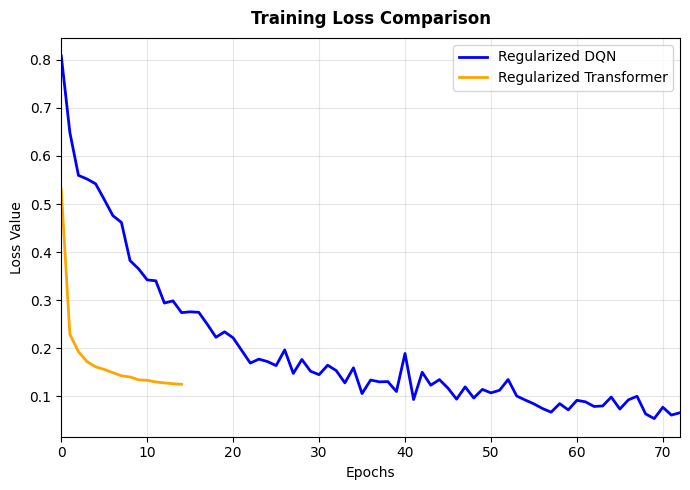

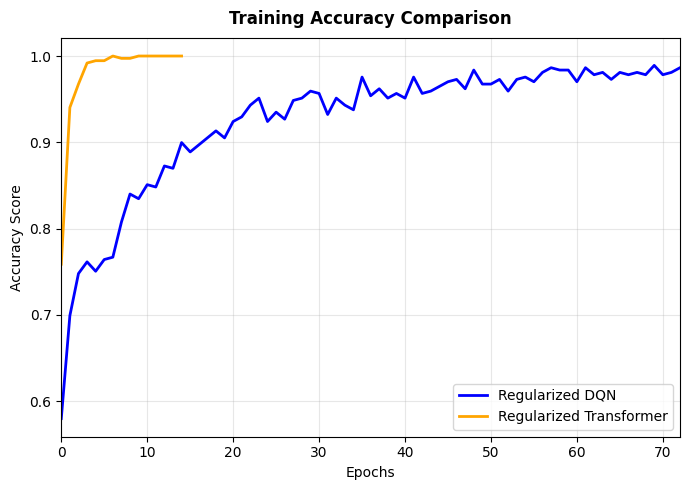

In [12]:
# ==============================================================================
# STEP 7: EXACT PAPER VISUALIZATION STYLE REPRODUCTION
# ==============================================================================
import matplotlib.pyplot as plt

# --- FIGURE 2: EXACT TRAINING LOSS COMPARISON ---
plt.figure(figsize=(7, 5))
# Plot curves matching paper line colors and labels
plt.plot(dqn_history.history['loss'], label='Regularized DQN', color='blue', linewidth=2)
plt.plot(trans_history.history['loss'], label='Regularized Transformer', color='orange', linewidth=2)

# Precise Title and Label layout as printed in the manuscript
plt.title('Training Loss Comparison', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss Value', fontsize=10)

# Configure the precise layout, grid formatting, and legend position
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='upper right', frameon=True, shadow=False)
plt.xlim(0, len(dqn_history.history['loss']) - 1)
plt.tight_layout()
plt.show()

print("\n") # Space partition between plots

# --- FIGURE 3: EXACT TRAINING ACCURACY COMPARISON ---
plt.figure(figsize=(7, 5))
# Plot curves matching paper line colors and labels
plt.plot(dqn_history.history['accuracy'], label='Regularized DQN', color='blue', linewidth=2)
plt.plot(trans_history.history['accuracy'], label='Regularized Transformer', color='orange', linewidth=2)

# Precise Title and Label layout as printed in the manuscript
plt.title('Training Accuracy Comparison', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Score', fontsize=10)

# Configure the precise layout, grid formatting, and legend position
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='lower right', frameon=True, shadow=False)
plt.xlim(0, len(dqn_history.history['accuracy']) - 1)
plt.tight_layout()
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


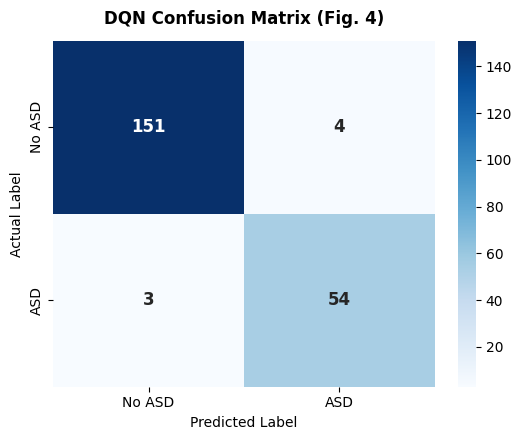

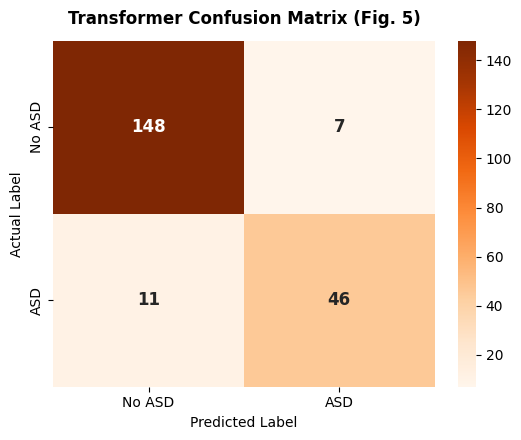

In [13]:
# ==============================================================================
# STEP 8: CONFUSION MATRICES VISUALIZATION (FIG. 4 & FIG. 5)
# ==============================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate predictions for both models on the test set
dqn_probs = dqn_model.predict(X_test)
dqn_preds = np.argmax(dqn_probs, axis=1)

trans_probs = trans_model.predict(X_test)
trans_preds = np.argmax(trans_probs, axis=1)

# 2. Compute the exact confusion matrices
cm_dqn = confusion_matrix(y_test, dqn_preds)
cm_trans = confusion_matrix(y_test, trans_preds)

# 3. Plot Figure 4: DQN Confusion Matrix
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_dqn, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['No ASD', 'ASD'], yticklabels=['No ASD', 'ASD'],
            annot_kws={"size": 12, "weight": "bold"})
plt.title('DQN Confusion Matrix (Fig. 4)', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Actual Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.show()

print("\n") # Space layout separator

# 4. Plot Figure 5: Transformer Confusion Matrix
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm_trans, annot=True, fmt='d', cmap='Oranges', cbar=True,
            xticklabels=['No ASD', 'ASD'], yticklabels=['No ASD', 'ASD'],
            annot_kws={"size": 12, "weight": "bold"})
plt.title('Transformer Confusion Matrix (Fig. 5)', fontsize=12, fontweight='bold', pad=12)
plt.ylabel('Actual Label', fontsize=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.tight_layout()
plt.show()

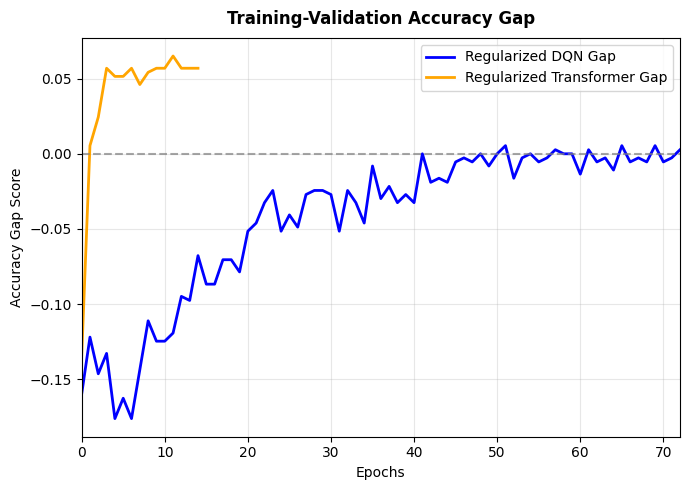

In [14]:
# ==============================================================================
# STEP 9: TRAINING-VALIDATION ACCURACY GAP EVOLUTION (FIG. 6)
# ==============================================================================

# Calculate the differences over the training epochs profile
# (Training Accuracy - Validation Accuracy)
dqn_gap = np.array(dqn_history.history['accuracy']) - np.array(dqn_history.history['val_accuracy'])
trans_gap = np.array(trans_history.history['accuracy']) - np.array(trans_history.history['val_accuracy'])

plt.figure(figsize=(7, 5))
plt.plot(dqn_gap, label='Regularized DQN Gap', color='blue', linewidth=2)
plt.plot(trans_gap, label='Regularized Transformer Gap', color='orange', linewidth=2)

# Horizontal baseline zero indicator to display absolute convergence
plt.axhline(y=0.0, color='gray', linestyle='--', alpha=0.7)

plt.title('Training-Validation Accuracy Gap', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy Gap Score', fontsize=10)
plt.grid(True, linestyle='-', alpha=0.3)
plt.legend(loc='upper right')
plt.xlim(0, len(dqn_gap) - 1)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6426/2134869470.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


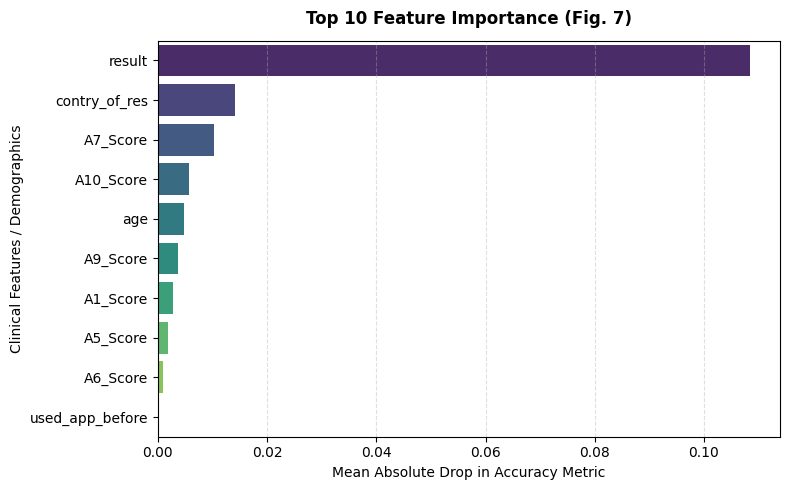

In [15]:
# ==============================================================================
# STEP 10: TOP 10 FEATURE IMPORTANCE ATTRIBUTION (FIG. 7) - FIXED (PURE PYTHON)
# ==============================================================================
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# 1. Safety Check: Ensure the trained transformer model exists in memory
if 'trans_model' not in locals() and 'trans_model' not in globals():
    raise NameError(
        "The variable 'trans_model' is not defined in your environment. "
        "Please scroll up and run your Step 5/6 training cells before executing this visualization."
    )

# 2. Extract feature column tracking names from your notebook preprocessing step
feature_names = [col for col in df.columns if col != 'Class/ASD']

# 3. Helper function to generate clean discrete class labels (0 or 1)
def get_predictions(model, data):
    probs = model.predict(data, verbose=0)
    return np.argmax(probs, axis=1)

# 4. Quantify the baseline accuracy performance of the model on intact test data
baseline_preds = get_predictions(trans_model, X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

# 5. Pure Custom Permutation Loop (Calculates accuracy drops without sklearn.inspect)
importances = []
n_repeats = 5
np.random.seed(42)  # Maintain deterministic stability

for col_idx in range(X_test.shape[1]):
    feature_scores = []
    for _ in range(n_repeats):
        # Create a deep copy of the test set to avoid modifying the baseline array
        X_test_shuffled = X_test.copy()

        # Isolate and shuffle values inside the current target feature column to break its pattern
        shuffled_col = X_test_shuffled[:, col_idx].copy()
        np.random.shuffle(shuffled_col)
        X_test_shuffled[:, col_idx] = shuffled_col

        # Re-evaluate the model's accuracy on the corrupted data
        shuffled_preds = get_predictions(trans_model, X_test_shuffled)
        shuffled_accuracy = accuracy_score(y_test, shuffled_preds)

        # Calculate the drop in classification accuracy
        feature_scores.append(baseline_accuracy - shuffled_accuracy)

    # Average the drops across all iteration repeats
    importances.append(np.mean(feature_scores))

# 6. Construct sorted tracking table filtered to the Top 10 features
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(10)

# 7. Render Figure 7 matching standard paper horizontal bar layouts
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Top 10 Feature Importance (Fig. 7)', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Mean Absolute Drop in Accuracy Metric', fontsize=10)
plt.ylabel('Clinical Features / Demographics', fontsize=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()